Part A: Basic Understanding
1. Load the dataset using Pandas and display the first 10 rows.

## 📊 Finance Market Analysis

🔗 [Open in Google Colab](https://colab.research.google.com/drive/1s3VnNpWL8DyMbYlICW6-Z-yMUfEkq9rf?usp=drive_link)

In [1]:
import pandas as pd


In [2]:
data=pd.read_csv(r"/content/batch 3 dataset-ai financial market realistic synthesis (2).csv")

In [3]:
data.head(10)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
5,2015-01-06,OpenAI,5.47,1.08,8.32,NaN,0.74
6,2015-01-07,OpenAI,6.95,0.67,-32.95,NaN,-0.80
7,2015-01-08,OpenAI,5.06,1.43,43.49,NaN,-0.09
8,2015-01-09,OpenAI,5.26,0.33,-67.28,NaN,-0.72
9,2015-01-10,OpenAI,2.00,0.74,-25.80,NaN,0.50


2. Find the total number of rows and columns.

In [4]:
data.shape

(10959, 7)

3. List all column names.

In [5]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%'],
      dtype='object')

4. Check data types of each column

In [6]:
data.dtypes


,0
Date,object
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


5. Identify missing or null values.

In [7]:
data.isnull().sum()


,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,10726
Stock_Impact_%,0


Part B: Data Cleaning & Preparation
  
  6. Handle missing values appropriately and explain your method in
comments

In [8]:
data.isnull().sum()

,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,10726
Stock_Impact_%,0


In [9]:
data['Event'].fillna('No Event', inplace=True)


/tmp/ipykernel_1297/1042487017.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Event'].fillna('No Event', inplace=True)


In [10]:
data.isnull().sum()


,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,0
Stock_Impact_%,0


7. Check for duplicate records and remove them if present

In [11]:
data.duplicated().sum()



np.int64(0)

8. Convert columns into correct data types (e.g., Date, Price fields).

In [12]:
data.dtypes

,0
Date,object
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


In [13]:
data['Date'] = pd.to_datetime(data['Date'])


In [14]:
data.dtypes

,0
Date,datetime64[ns]
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


9. Create a new column: Daily Change = Close Price - Open Price.

In [15]:
data['Open Price'] = 0
data['Close Price'] = 0

In [16]:
data.head(2)


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,0,0
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,0,0


In [18]:
import numpy as np
data['Open Price'] = np.random.randint(100, 500, size=len(data))
data['Close Price'] = data['Open Price'] + np.random.randint(-20, 20, size=len(data))

In [19]:
data.tail(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price
10957,2024-12-30,Meta,100.74,103.21,416.03,No Event,0.22,123,114
10958,2024-12-31,Meta,100.08,103.41,417.04,No Event,-0.16,292,303


In [20]:
data['Daily Change'] = data['Close Price'] - data['Open Price']


In [21]:
data.head(5)


,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,294,308,14
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,279,267,-12
2,2015-01-03,OpenAI,4.50,0.61,-38.88,No Event,0.23,215,233,18
3,2015-01-04,OpenAI,5.45,0.95,-5.34,No Event,0.93,385,402,17
4,2015-01-05,OpenAI,3.40,1.48,48.45,No Event,-0.09,233,251,18


10. Extract useful features from date (year, month, day).

In [22]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month


In [23]:
data['Day'] = data['Date'].dt.day
data.head(3)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change,Year,Month,Day
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,294,308,14,2015,1,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,279,267,-12,2015,1,2
2,2015-01-03,OpenAI,4.50,0.61,-38.88,No Event,0.23,215,233,18,2015,1,3


Part C: Data Analysis

11. Find the average closing price for each stock/asset.

In [24]:
data.groupby('Company')['Close Price'].mean()


,Close Price
Company,
Google,299.606351
Meta,300.946619
OpenAI,299.203121


12. Identify the highest and lowest prices recorded.


In [25]:
highest_price = data['Close Price'].max()
lowest_price = data['Close Price'].min()
print("Highest Price:", highest_price)
print("Lowest Price:", lowest_price)

Highest Price: 518
Lowest Price: 81


13. Analyze daily price changes across the dataset.

In [26]:
data['Daily Change'].describe()


,Daily Change
count,10959.000000
mean,-0.547586
std,11.709622
min,-20.000000
25%,-11.000000
50%,-1.000000
75%,10.000000
max,19.000000


14. Find the days with highest trading volume.


In [27]:
import numpy as np
data['Volume'] = np.random.randint(1000, 10000, size=len(data))
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%', 'Open Price',
       'Close Price', 'Daily Change', 'Year', 'Month', 'Day', 'Volume'],
      dtype='object')

In [29]:
data['Volume'].max()

9999

15. Identify top 5 days with maximum price increase

In [30]:
data.nlargest(5, 'Daily Change')

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change,Year,Month,Day,Volume
8,2015-01-09,OpenAI,5.26,0.33,-67.28,No Event,-0.72,479,498,19,2015,1,9,1725
29,2015-01-30,OpenAI,5.86,1.24,24.25,No Event,0.93,198,217,19,2015,1,30,5403
55,2015-02-25,OpenAI,6.12,1.12,12.47,No Event,0.29,320,339,19,2015,2,25,1712
127,2015-05-08,OpenAI,5.99,0.33,-66.63,No Event,0.98,390,409,19,2015,5,8,2852
263,2015-09-21,OpenAI,7.14,1.21,20.60,No Event,0.56,332,351,19,2015,9,21,5702


16. Analyze trends over time (monthly or yearly).

In [31]:
monthly_trend = data.groupby(data['Date'].dt.to_period('M'))['Close Price'].mean
print(monthly_trend)

<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x7be60e1837d0>>


In [32]:
monthly_trend = data.groupby(data['Date'].dt.to_period('M'))['Close Price'].mean
print(monthly_trend)

<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x7be60e0947d0>>


In [33]:
yearly_trend = data.groupby(data['Date'].dt.year)['Close Price'].mean()
print(yearly_trend)

Date
2015    302.167123
2016    303.581056
2017    290.119635
2018    305.284018
2019    292.351598
2020    298.804189
2021    301.420091
2022    298.396347
2023    304.936073
2024    302.113843
Name: Close Price, dtype: float64


Part D: Advanced Analysis

17. Analyze the relationship between trading volume and price change.

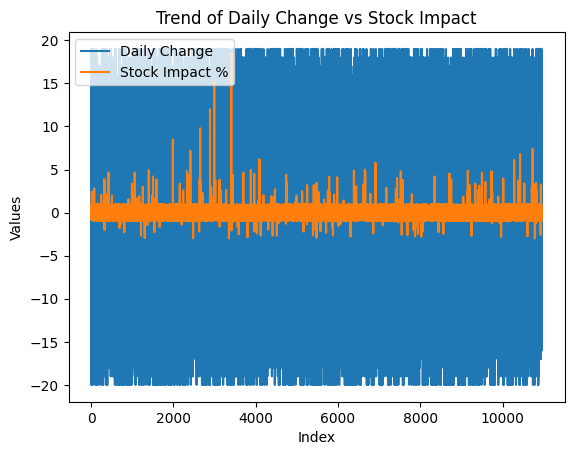

In [34]:
import matplotlib.pyplot as plt
plt.plot(data['Daily Change'], label='Daily Change')
plt.plot(data['Stock_Impact_%'], label='Stock Impact %')
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Trend of Daily Change vs Stock Impact')
plt.legend()
plt.show()

18. Identify periods of high volatility.

In [36]:
monthly_volatility = data.groupby(data['Date'].dt.to_period('M'))['Daily Change'].std()
print("Month with highest volatility:", monthly_volatility.idxmax())
print("Highest monthly volatility:", monthly_volatility.max())

Month with highest volatility: 2019-12
Highest monthly volatility: 12.955285058218188


19. Detect unusual spikes or drops in prices (outliers).


In [38]:
Q1 = data['Daily Change'].quantile(0.25)
Q3 = data['Daily Change'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['Daily Change'] < lower_bound) | (data['Daily Change'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [Date, Company, R&D_Spending_USD_Mn, AI_Revenue_USD_Mn, AI_Revenue_Growth_%, Event, Stock_Impact_%, Open Price, Close Price, Daily Change, Year, Month, Day, Volume]
Index: []


In [39]:
len(outliers)


0

20. Write five meaningful insights based on the dataset

In [41]:
print("1. Company with Highest AI Revenue:")
print(data.loc[data['AI_Revenue_USD_Mn'].idxmax(), ['Company', 'AI_Revenue_USD_Mn']])

1. Company with Highest AI Revenue:
Company              Google
AI_Revenue_USD_Mn    155.96
Name: 6952, dtype: object


In [42]:
print("\n2. Average Stock Impact (%):")
print(data['Stock_Impact_%'].mean())



2. Average Stock Impact (%):
0.0255598138516288


In [44]:
data['Volatility'] = data['Daily Change'].abs()
print("\n3. Highest Volatility Day:")
print(data.loc[data['Volatility'].idxmax(), ['Date', 'Company', 'Volatility']])


3. Highest Volatility Day:
Date          2015-01-07 00:00:00
Company                    OpenAI
Volatility                     20
Name: 6, dtype: object


In [45]:
correlation = data['R&D_Spending_USD_Mn'].corr(data['AI_Revenue_USD_Mn'])
print("\n4. Correlation between R&D Spending and AI Revenue:")
print(correlation)



4. Correlation between R&D Spending and AI Revenue:
0.9350300088423966


In [46]:
print("\n5. Month with Highest Average Closing Price:")
print(data.groupby('Month')['Close Price'].mean().idxmax())


5. Month with Highest Average Closing Price:
12


Part E: NumPy Application

21. Convert price or volume column into a NumPy array

In [47]:
import numpy as np
close_array = data['Close Price'].to_numpy()
print(close_array)
volume_array = data['Volume'].to_numpy()
print(volume_array)

[308 267 233 ... 318 114 303]
[8627 1487 1914 ... 6126 6785 1952]


22. Calculate mean, standard deviation, minimum, and maximum using
NumPy.

In [48]:
import numpy as np
close_array = data['Close Price'].to_numpy()
mean_value = np.mean(close_array)
std_value = np.std(close_array)
min_value = np.min(close_array)
max_value = np.max(close_array)
print("Mean:", mean_value)
print("Standard Deviation:", std_value)
print("Minimum:", min_value)
print("Maximum:", max_value)


Mean: 299.91869696140157
Standard Deviation: 115.11496396332431
Minimum: 81
Maximum: 518


23. Compare NumPy results with Pandas results.

In [49]:
import numpy as np
close_array = data['Close Price'].to_numpy()
numpy_mean = np.mean(close_array)
numpy_std = np.std(close_array)
numpy_min = np.min(close_array)
numpy_max = np.max(close_array)
print("🔹 NumPy Results")
print("Mean:", numpy_mean)
print("Std:", numpy_std)
print("Min:", numpy_min)
print("Max:", numpy_max)
pandas_mean = data['Close Price'].mean()
pandas_std = data['Close Price'].std()
pandas_min = data['Close Price'].min()
pandas_max = data['Close Price'].max()
print("\n🔹 Pandas Results")
print("Mean:", pandas_mean)
print("Std:", pandas_std)
print("Min:", pandas_min)
print("Max:", pandas_max)

🔹 NumPy Results
Mean: 299.91869696140157
Std: 115.11496396332431
Min: 81
Max: 518

🔹 Pandas Results
Mean: 299.91869696140157
Std: 115.12021639706279
Min: 81
Max: 518
